In [2]:
import pandas as pd
import random
import math
import numpy as np

df_rating = pd.read_csv('./ratings_small.csv')
df_movies = pd.read_csv('./movies_metadata.csv')

/var/folders/4x/r5jmfhy116jd35yzhz5phw0w0000gn/T/ipykernel_80704/943428136.py:7: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_movies = pd.read_csv('./movies_metadata.csv')


In [3]:
print(df_movies.shape[0])
print(df_rating.shape[0])

cols_to_numeric = ['budget', 'popularity']

for col in cols_to_numeric:
    df_movies[col] = pd.to_numeric(df_movies[col], errors='coerce')

df_movies['id'] = pd.to_numeric(df_movies['id'], errors='coerce')



df_movies['budget_log'] = np.log(df_movies['budget'])
df_movies['popularity_log'] = np.log(df_movies['popularity'])

df_movies.describe()
df_movies.columns.tolist()

merged = pd.merge(
    df_rating, 
    df_movies, 
    left_on='movieId',
    right_on='id'
)

merged.shape


45466
100004


/Users/dashanalivayko/Library/Python/3.11/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/dashanalivayko/Library/Python/3.11/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/dashanalivayko/Library/Python/3.11/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/dashanalivayko/Library/Python/3.11/lib/python/site-packages/numpy/lib/_function_base_impl.py:4592: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/Users/dashanalivayko/Library/Python/3.11/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


(44994, 30)

In [4]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import json
from sklearn.preprocessing import MultiLabelBinarizer

merged['target'] = (merged['rating'] >= 4).astype(int)

df_classification = merged[['vote_average', 'userId', 'movieId', 'target']]

df_classification.isnull().sum()

X = df_classification[['vote_average']]
y = df_classification['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_train.value_counts()


# print(classification_report(y_test, y_pred))
merged['genres'].iloc[0]

def movie_genres(row):
    try:
        genres = json.loads(row.replace("'", '"'))
        genre_names = [genre['name'] for genre in genres]
        return genre_names
    except json.JSONDecodeError:
        return []

movie_genres(merged['genres'].iloc[0])

merged['genre_names'] = merged['genres'].apply(movie_genres)

mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(merged['genre_names'])
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_)

merged = pd.concat([merged, genre_df], axis=1)


In [5]:
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import FunctionTransformer, StandardScaler
# from sklearn.cluster import KMeans

# pipe = Pipeline([
#     ('scaler',  StandardScaler()),
#     ('kmeans',  KMeans(n_clusters=10, random_state=42, n_init=10)),
# ])

# labels = pipe.fit_predict(df.drop(['timestamp']))

In [6]:
m = df_movies['vote_count'].quantile(0.90)
C = df_movies['vote_average'].mean()

def weighted_rating(row, m=m, C=C):
    v = row['vote_count']
    R = row['vote_average']
    return round((v / (v + m)) * R + (m / (v + m)) * C, 2)

df_movies['score'] = df_movies.apply(weighted_rating, axis=1)
df_movies = df_movies.drop_duplicates(subset='title')

In [7]:
df =df_movies.drop(columns=['adult', 'belongs_to_collection','homepage','id', 'imdb_id','original_title','poster_path','production_countries', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'video', 'vote_count', 'vote_average', 'budget'])


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['overview'].fillna(''))

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
cosine_sim

indices = pd.Series(df_movies.index, index=df_movies['title']).drop_duplicates()

def get_recommendations(title, cosine_sim=cosine_sim, df=df_movies, indices=indices):
    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:6]

    movie_indices = [i[0] for i in sim_scores]
    return df['title'].iloc[movie_indices]



In [9]:
get_recommendations('Toy Story')

15348                    Toy Story 3
2997                     Toy Story 2
10301         The 40 Year Old Virgin
24523                      Small Fry
23843    Andy Hardy's Blonde Trouble
Name: title, dtype: object

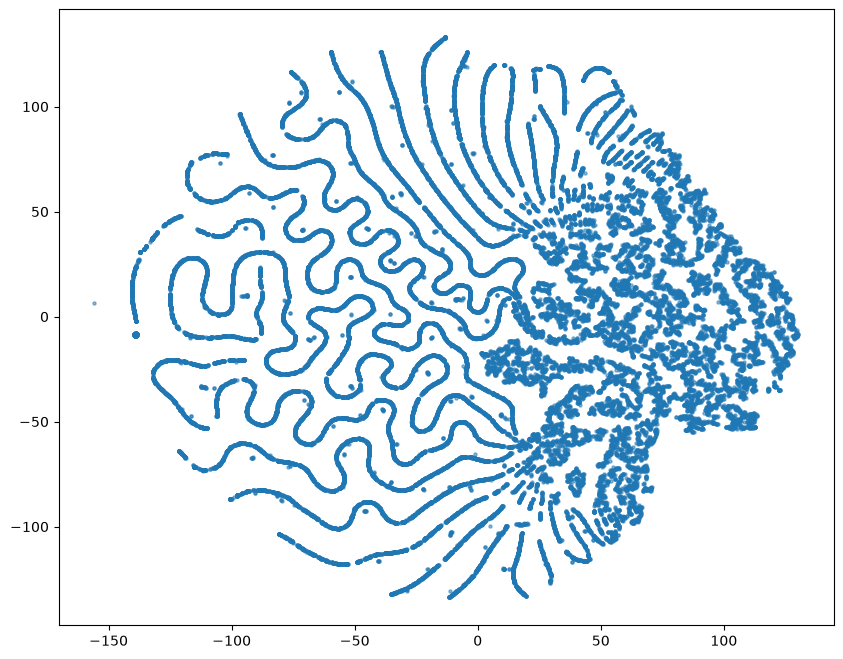

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

features = df_movies[['budget', 'popularity', 'score']].dropna()

scaled = StandardScaler().fit_transform(features)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(scaled)

plt.figure(figsize=(10, 8))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.5, s=5)
plt.show()


In [11]:
features = df_movies[['popularity_log', 'score']].dropna()


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Выбираем признаки (vote_average + все жанры)
genre_columns = [col for col in merged.columns if col in mlb.classes_]
X = merged[['vote_average'] + genre_columns]
y = merged['target']

# Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучаем модель
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Предсказываем
y_pred = model.predict(X_test)

# Метрики
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.20      0.29      4290
           1       0.54      0.84      0.66      4709

    accuracy                           0.54      8999
   macro avg       0.54      0.52      0.47      8999
weighted avg       0.54      0.54      0.48      8999



cluster
0    1659
2     999
1     172
Name: count, dtype: int64


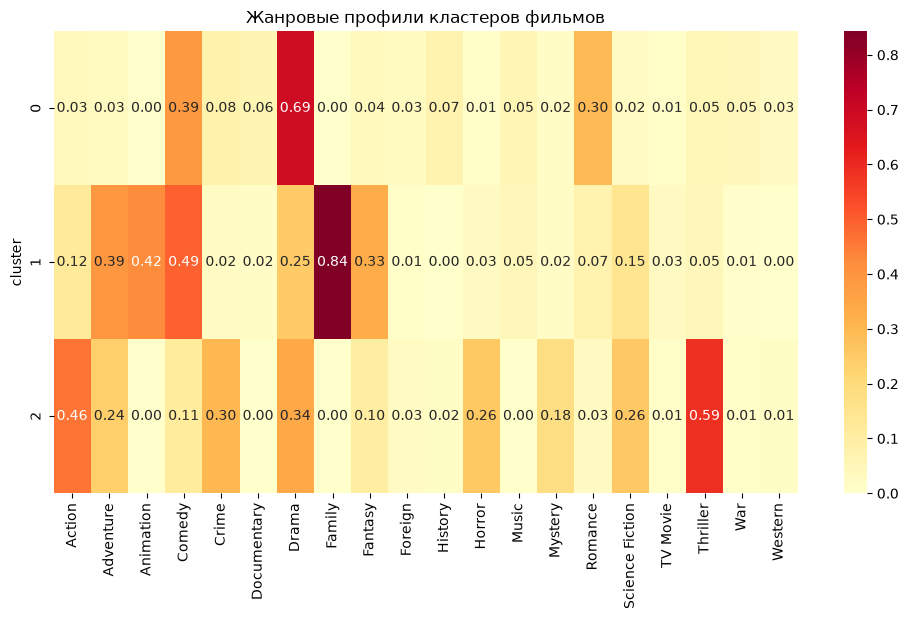

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

# Выбираем признаки
genre_columns = [col for col in merged.columns if col in mlb.classes_]
features_for_clustering = merged[['vote_average', 'popularity'] + genre_columns].copy()

# Удаляем дубликаты по movieId
movies_unique = merged.drop_duplicates(subset='movieId')[['movieId', 'vote_average', 'popularity'] + genre_columns].copy()

# Масштабируем
scaler = StandardScaler()
scaled_features = scaler.fit_transform(movies_unique[['vote_average', 'popularity'] + genre_columns])

# Кластеризуем (пусть будет 5 кластеров)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
movies_unique['cluster'] = kmeans.fit_predict(scaled_features)

print(movies_unique['cluster'].value_counts())

cluster_profiles = movies_unique.groupby('cluster')[genre_columns].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles, cmap='YlOrRd', annot=True, fmt='.2f')
plt.title('Жанровые профили кластеров фильмов')
plt.show()


In [19]:
# Для каждого пользователя строим профиль жанров
user_profiles = []

for user_id in merged['userId'].unique():
    user_data = merged[merged['userId'] == user_id]
    liked_movies = user_data[user_data['rating'] >= 4]
    
    if len(liked_movies) > 0:
        # Средние значения жанров для фильмов, которые понравились
        genre_profile = liked_movies[genre_columns].mean()
        genre_profile['userId'] = user_id
        user_profiles.append(genre_profile)

users_df = pd.DataFrame(user_profiles)

# Масштабируем и кластеризуем
scaler_users = StandardScaler()
scaled_users = scaler_users.fit_transform(users_df[genre_columns])

kmeans_users = KMeans(n_clusters=5, random_state=42, n_init=10)
users_df['cluster'] = kmeans_users.fit_predict(scaled_users)

print(users_df['cluster'].value_counts())


cluster
1    388
2    176
3     78
0     26
4      1
Name: count, dtype: int64


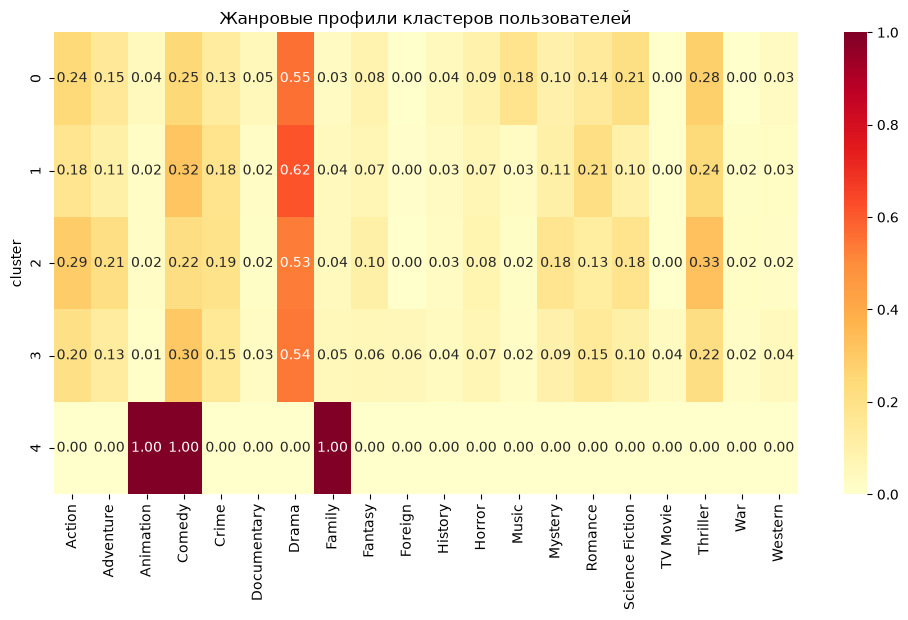

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

user_cluster_profiles = users_df.groupby('cluster')[genre_columns].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(user_cluster_profiles, cmap='YlOrRd', annot=True, fmt='.2f')
plt.title('Жанровые профили кластеров пользователей')
plt.show()


In [25]:
user_movie_matrix = merged.pivot_table(
    index='userId', 
    columns='movieId', 
    values='rating'
).fillna(0)

print(user_movie_matrix)

cosine_sim = cosine_similarity(user_movie_matrix)
cosine_sim


movieId  2       3       5       6       11      12      13      14      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           0.0     4.0     0.0     0.0     0.0     0.0     0.0     0.0   
...         ...     ...     ...     ...     ...     ...     ...     ...   
667         0.0     0.0     0.0     4.0     3.0     0.0     0.0     0.0   
668         0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
669         0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
670         0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
671         0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  15      16     

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.17289957, ..., 0.04433851, 0.17307257,
        0.10907781],
       [0.        , 0.17289957, 1.        , ..., 0.10607371, 0.22474113,
        0.20630672],
       ...,
       [0.        , 0.04433851, 0.10607371, ..., 1.        , 0.        ,
        0.12258009],
       [0.        , 0.17307257, 0.22474113, ..., 0.        , 1.        ,
        0.20027667],
       [0.        , 0.10907781, 0.20630672, ..., 0.12258009, 0.20027667,
        1.        ]], shape=(671, 671))

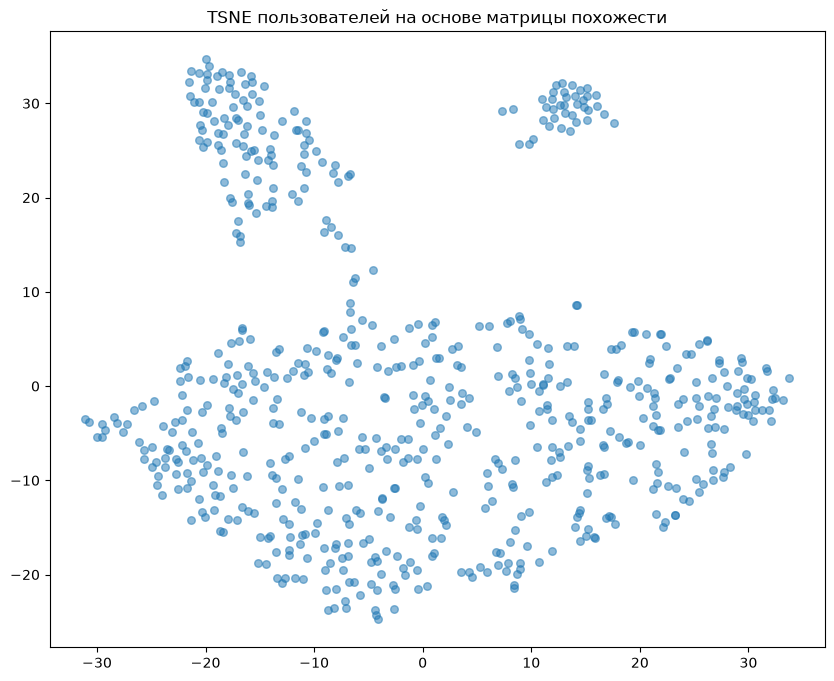

In [32]:
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

distance_matrix = 1 - cosine_sim

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(distance_matrix)

plt.figure(figsize=(10, 8))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.5, s=30)
plt.title('TSNE пользователей на основе матрицы похожести')
plt.show()


In [71]:
def watched_movies(user_id):
    return merged[merged['userId'] == user_id]['movieId'].tolist()

def find_similar_users(user_id, top_n=5):
    if user_id not in user_movie_matrix.index:
        return []
    
    user_idx = user_movie_matrix.index.get_loc(user_id)
    sim_scores = list(enumerate(cosine_sim[user_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    similar_users = [user_movie_matrix.index[i[0]] for i in sim_scores[1:top_n+1]]
    return [int(u) for u in similar_users]

find_similar_users(5)

# # выводим рекомендации для пользователя с ID 5
def recomend_movies_for_user(user_id, top_n=5):
    similar_users = find_similar_users(user_id, top_n)
    recommended_movies = set()
    
    for sim_user in similar_users:
        movies = watched_movies(sim_user)
        recommended_movies.update(movies)
    
    user_movies = set(watched_movies(user_id))
    recommended_movies.difference_update(user_movies)

    recommended_movies_data = merged[merged['id'].isin(recommended_movies)].drop_duplicates(subset='id')
    recommended_movies_sorted = recommended_movies_data.sort_values('rating', ascending=False)
    recommended_indexs = list(recommended_movies_sorted['id'].values)[:top_n]

    for i in recommended_indexs:
        movie_title = df_movies[df_movies['id'] == i]['title'].values[0]
        print(f"Movie ID: {i}, Title: {movie_title}, Rating: {recommended_movies_sorted[recommended_movies_sorted['id'] == i]['rating'].values[0]}")


recomend_movies_for_user(5)

# def recomend_movies_for_user(user_id, top_n=5):
#     similar_users = find_similar_users(user_id, top_n)
#     recommended_movies = {}
    
#     for sim_user in similar_users:
#         user_movies = merged[merged['userId'] == sim_user]
#         for _, row in user_movies.iterrows():
#             movie_id = row['movieId']
#             if movie_id not in recommended_movies:
#                 recommended_movies[movie_id] = []
#             recommended_movies[movie_id].append(row['rating'])
    
#     user_movies = set(watched_movies(user_id))
#     recommended_movies = {k: v for k, v in recommended_movies.items() if k not in user_movies}
    
#     # Берем среднюю оценку похожих пользователей
#     recommended_movies = {k: sum(v)/len(v) for k, v in recommended_movies.items()}
#     sorted_movies = sorted(recommended_movies.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
#     for movie_id, avg_rating in sorted_movies:
#         movie_title = merged[merged['movieId'] == movie_id]['title'].values[0]
#         print(f"Movie ID: {movie_id}, Title: {movie_title}, Avg Rating from Similar Users: {avg_rating:.2f}")

# recomend_movies_for_user(5)



def favorite_movies(user_id, top_n=5):
    user_data = merged[merged['userId'] == user_id]
    top_movies = user_data.sort_values(by='rating', ascending=False).head(top_n)

    for _, row in top_movies.iterrows():
        print(f"\nMovie ID: {row['id']}, Title: {row['title']}, Rating: {row['rating']}")

favorite_movies(5)

Movie ID: 553, Title: Dogville, Avg Rating from Similar Users: 5.00
Movie ID: 1213, Title: The Talented Mr. Ripley, Avg Rating from Similar Users: 5.00
Movie ID: 58559, Title: Confession of a Child of the Century, Avg Rating from Similar Users: 5.00
Movie ID: 1597, Title: Meet the Parents, Avg Rating from Similar Users: 5.00
Movie ID: 8908, Title: Maradona by Kusturica, Avg Rating from Similar Users: 5.00

Movie ID: 1380.0, Title: Gleaming the Cube, Rating: 5.0

Movie ID: 33166.0, Title: Downhill Racer, Rating: 5.0

Movie ID: 597.0, Title: Titanic, Rating: 5.0

Movie ID: 48385.0, Title: Indestructible Man, Rating: 4.5

Movie ID: 500.0, Title: Reservoir Dogs, Rating: 4.5
